# Phase 0: Setup
Setting up FastF1 where we will be gathering our data for the project

In [27]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fastf1.Cache.enable_cache("../cache/")

# Phase 1: EDA: Bahrain Grand Prix 2023 analysis


We are starting by analyzing one race, preferably in a race where the circuit is pretty stable with overtaking opportunities, balanced pace etc. One of the choices is the Bahrain circuit, it's special because it's where tyre degradation appears to be and there are lots of overtakings, one of the reasons why it's the pre-season testing circuit so it's where teams actually test their cars before the season begins.

We load and analyze the race data

In [28]:
bahrain2023_race = fastf1.get_session(2023, "Bahrain", "R")
bahrain2023_race.load()
laps = bahrain2023_race.laps

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']


In [29]:
print(laps.shape)
print(laps.columns)
print(laps.dtypes)
print(laps.head())


(1056, 31)
Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')
Time                  timedelta64[ns]
Driver                         object
DriverNumber                   object
LapTime               timedelta64[ns]
LapNumber                     float64
Stint                         float64
PitOutTime            timedelta64[ns]
PitInTime             timedelta64[ns]
Sector1Time           timedelta64[ns]
Sector2Time           timedelta64[ns]
Sector3Time           timedelta64[ns]
Sector1SessionTime    timedelta64[ns]
Sector2SessionTime    timedel

## Feature Engineering and cleaning

Before going forward we have to clean our data, there are laps that don't count, either in/out laps, laps under safety car, invalid laps etc and we need to fixate on one driver to actually have a consistent experiment piece

In [30]:
laps["LapTimeSeconds"] = laps["LapTime"].dt.total_seconds()
laps["Stint"] = laps["Stint"].astype(int)
clean_laps = laps[laps["IsAccurate"] == True]
drivers = clean_laps["Driver"].unique()
for d in drivers:
    ds = clean_laps[clean_laps["Driver"] == d].Stint.unique()
    print("Driver: ", d)
    print(ds)
    for s in ds:
        print(f"stint {s}: ", clean_laps[(clean_laps["Driver"] == d) & (clean_laps["Stint"] == s)].shape[0])

Driver:  VER
[1 2 3]
stint 1:  12
stint 2:  20
stint 3:  18
Driver:  GAS
[1 2 3 4]
stint 1:  7
stint 2:  14
stint 3:  13
stint 4:  16
Driver:  PER
[1 2 3]
stint 1:  15
stint 2:  15
stint 3:  20
Driver:  ALO
[1 2 3]
stint 1:  12
stint 2:  18
stint 3:  21
Driver:  LEC
[1 2 3]
stint 1:  11
stint 2:  18
stint 3:  5
Driver:  STR
[1 2 3]
stint 1:  13
stint 2:  13
stint 3:  24
Driver:  SAR
[1 2 3 4]
stint 1:  10
stint 2:  16
stint 3:  8
stint 4:  15
Driver:  MAG
[1 2 3 4]
stint 1:  13
stint 2:  12
stint 3:  9
stint 4:  15
Driver:  DEV
[1 2 3]
stint 1:  9
stint 2:  14
stint 3:  26
Driver:  TSU
[1 2 3 4]
stint 1:  8
stint 2:  14
stint 3:  12
stint 4:  16
Driver:  ALB
[1 2 3 4]
stint 1:  9
stint 2:  13
stint 3:  12
stint 4:  16
Driver:  ZHO
[1 2 3 4]
stint 1:  10
stint 2:  18
stint 3:  18
stint 4:  1
Driver:  HUL
[1 2 3 4]
stint 1:  9
stint 2:  13
stint 3:  12
stint 4:  15
Driver:  OCO
[1 2 3 4]
stint 1:  10
stint 2:  1
stint 3:  15
stint 4:  6
Driver:  NOR
[1 2 3 4 5 6]
stint 1:  8
stint 2:  5


Lap: 2 Tyre age: 5 Laptime: 97.974
Lap: 3 Tyre age: 6 Laptime: 98.006
Lap: 4 Tyre age: 7 Laptime: 97.976
Lap: 5 Tyre age: 8 Laptime: 98.035
Lap: 6 Tyre age: 9 Laptime: 97.986
Lap: 7 Tyre age: 10 Laptime: 98.021
Lap: 8 Tyre age: 11 Laptime: 98.154
Lap: 9 Tyre age: 12 Laptime: 98.278
Lap: 10 Tyre age: 13 Laptime: 98.369
Lap: 11 Tyre age: 14 Laptime: 98.483
Lap: 12 Tyre age: 15 Laptime: 98.591
Lap: 13 Tyre age: 16 Laptime: 98.482
Lap: 16 Tyre age: 2 Laptime: 97.801
Lap: 17 Tyre age: 3 Laptime: 97.648
Lap: 18 Tyre age: 4 Laptime: 97.614
Lap: 19 Tyre age: 5 Laptime: 97.712
Lap: 20 Tyre age: 6 Laptime: 97.788
Lap: 21 Tyre age: 7 Laptime: 97.582
Lap: 22 Tyre age: 8 Laptime: 97.651
Lap: 23 Tyre age: 9 Laptime: 97.552
Lap: 24 Tyre age: 10 Laptime: 97.387
Lap: 25 Tyre age: 11 Laptime: 97.372
Lap: 26 Tyre age: 12 Laptime: 97.682
Lap: 27 Tyre age: 13 Laptime: 97.379
Lap: 28 Tyre age: 14 Laptime: 97.651
Lap: 29 Tyre age: 15 Laptime: 97.571
Lap: 30 Tyre age: 16 Laptime: 97.549
Lap: 31 Tyre age: 17 L

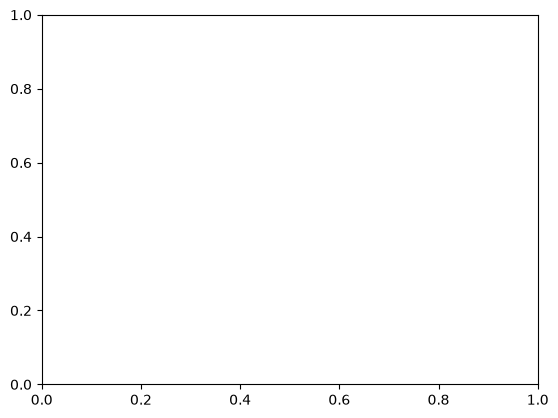

In [43]:
for d in drivers:
    ds = clean_laps[clean_laps["Driver"] == d].Stint.unique()
    for s in ds:
        driver_stint = clean_laps[(clean_laps["Driver"] == d) & (clean_laps["Stint"] == s)]
        for i in driver_stint.index:
            print(f"Lap: {driver_stint.loc[i, 'LapNumber'].astype(int)} Tyre age: {driver_stint.loc[i, 'TyreLife'].astype(int)} Laptime: {driver_stint.loc[i, 'LapTimeSeconds']}")
        plt.xlabel("Tyre Age")
        plt.ylabel("Lap Time")
        plt.title(f"{d} Stint {s} Compound: {driver_stint.loc[i, 'Compound']} Bahrain 2023 laptime evolution by tyre age (Lower is faster)")
        plt.plot(np.array(driver_stint['TyreLife'].astype(int)), np.array(driver_stint['LapTimeSeconds']))
        plt.savefig(f"../figs/bahrain2023_{d}_stint{s}_{driver_stint.loc[i, 'Compound']}_tyredeg_evo.png")
        plt.cla()


Lap: 16 Tyre age: 2 Laptime: 97.801
Lap: 17 Tyre age: 3 Laptime: 97.648
Lap: 18 Tyre age: 4 Laptime: 97.614
Lap: 19 Tyre age: 5 Laptime: 97.712
Lap: 20 Tyre age: 6 Laptime: 97.788
Lap: 21 Tyre age: 7 Laptime: 97.582
Lap: 22 Tyre age: 8 Laptime: 97.651
Lap: 23 Tyre age: 9 Laptime: 97.552
Lap: 24 Tyre age: 10 Laptime: 97.387
Lap: 25 Tyre age: 11 Laptime: 97.372
Lap: 26 Tyre age: 12 Laptime: 97.682
Lap: 27 Tyre age: 13 Laptime: 97.379
Lap: 28 Tyre age: 14 Laptime: 97.651
Lap: 29 Tyre age: 15 Laptime: 97.571
Lap: 30 Tyre age: 16 Laptime: 97.549
Lap: 31 Tyre age: 17 Laptime: 97.431
Lap: 32 Tyre age: 18 Laptime: 97.691
Lap: 33 Tyre age: 19 Laptime: 97.686
Lap: 34 Tyre age: 20 Laptime: 97.839
Lap: 35 Tyre age: 21 Laptime: 97.85


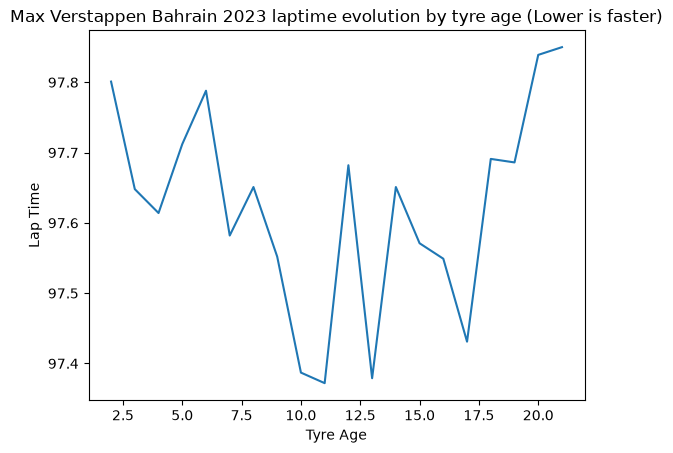

In [32]:
ver_stint2 = clean_laps[(clean_laps["Driver"] == "VER") & (clean_laps["Stint"] == 2)]
for i in ver_stint2.index:
    print(f"Lap: {ver_stint2.loc[i, 'LapNumber'].astype(int)} Tyre age: {ver_stint2.loc[i, 'TyreLife'].astype(int)} Laptime: {ver_stint2.loc[i, 'LapTimeSeconds']}")
plt.xlabel("Tyre Age")
plt.ylabel("Lap Time")
plt.title("Max Verstappen Bahrain 2023 laptime evolution by tyre age (Lower is faster)")
plt.plot(np.array(ver_stint2['TyreLife'].astype(int)), np.array(ver_stint2['LapTimeSeconds']))
plt.show()